In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

import numpy as np
from scipy.sparse import bmat, diags, block_diag
from scipy.sparse.linalg import expm_multiply

from lattice import Graphene


def plot_graphene(na, nb, Cna, Cnb, ax, s=5, cmap="hot", vmin=None, vmax=None, logscale=None):
    if logscale:
        Cna = np.log10(Cna)
        Cnb = np.log10(Cnb)

    im = ax.scatter(na[0], na[1] ,c=Cna, s=s, label="A", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.scatter(nb[0], nb[1], c=Cnb, s=s, label="B", cmap=cmap, vmin=vmin, vmax=vmax)

    return im

Text(0, 0.5, 'Eigenvalues')

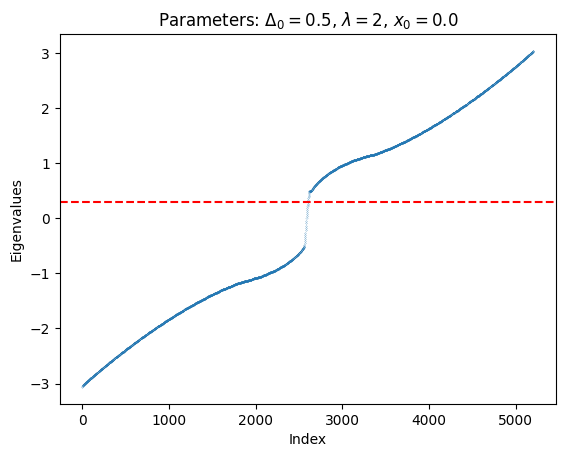

In [3]:
nmax = 51
delta = 0.5
lambda_0 = 2
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.axhline(0.3, color="red", linestyle="dashed")
plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

0.0001710832288367823


Text(0.5, 0, 'x')

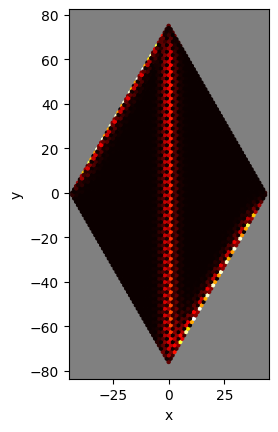

In [87]:
idx = np.where(eigval > 0)[0][0] # get the first positive
psi = np.asarray(eigvec[:, idx]).flatten()

print(eigval[idx])

psi_a = psi[:lattice.la]
psi_b = psi[lattice.la:]


na, nb = lattice.n_real_pos
Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2


fig, ax = plt.subplots()

plot_graphene(na, nb, Cna, Cnb, ax)

ax.set_aspect("equal")
ax.set_xlim(-45, 45)

ax.set_facecolor("gray")

ax.set_ylabel("y")
ax.set_xlabel("x")

In [11]:
from scipy.special import gamma

In [ ]:
def psi_analytic(x, y, ky, delta_0, lambda_0, tau):
    vf = 3./2 # 3(aJ) / 2
    beta = delta_0 * lambda_0 / vf

    N = np.sqrt(
        1/(2 * lambda_0 * np.sqrt(np.pi)) * gamma(beta/2 + 1/2) /gamma(beta)
    ) * np.cosh(x0/lambda_0) ** (-beta)

    # N = np.sqrt(gamma(beta + 1/2) / (np.sqrt(np.pi) * lambda_0 * gamma(beta)))
    expr = np.exp(1j * ky * y) * (np.cosh((x-x0)/lambda_0)/np.cosh(x0/lambda_0)) ** (-beta)

    psi_a = N * expr
    psi_b = 1j * tau * psi_a

    return psi_a, psi_b

In [100]:
def full_psi(lattice, delta_0, lambda_0):
  na, nb = lattice.n_real_pos
  psi_a1, psi_b1 = psi_analytic(na[0], na[1], ky = 0, delta_0=delta_0, lambda_0=lambda_0, tau=1)
  psi_a2, psi_b2 = psi_analytic(na[0], na[1], ky = 0, delta_0=delta_0, lambda_0=lambda_0, tau=-1)

  # normalization is broken, therefore we are going to normalize it numerically
  # norm1 = np.sqrt(np.vdot(psi_a1, psi_a1))
  # norm2 = np.sqrt(np.vdot(psi_a2, psi_a2))

  # psi_a1 /= norm1
  # psi_b1 /= norm1
  # psi_a2 /= norm2
  # psi_b2 /= norm2

  K = 4 * np.pi/3
  Kprime = -K

  psi_a = np.exp(1j * K * na[0]) * psi_a1 + np.exp(1j * Kprime * na[0]) * psi_a2
  psi_b = np.exp(1j * K * nb[0]) * psi_b1 + np.exp(1j * Kprime * nb[0]) * psi_b2

  psi_a /= np.sqrt(np.vdot(psi_a, psi_a))
  psi_b /= np.sqrt(np.vdot(psi_b, psi_b))

  return psi_a, psi_b




In [109]:
na, nb = lattice.n_real_pos
psi_a, psi_b = psi_analytic(na[0], na[1], ky = 0, delta_0=0.5, lambda_0=2, tau=-1)

# norm = np.sqrt(np.vdot(psi_a, psi_a))
# psi_a /= norm

# norm = np.sqrt(np.vdot(psi_b, psi_b))

# psi_b /= norm


In [110]:
np.vdot(psi_a, psi_a) + np.vdot(psi_b, psi_b)

np.complex128(68.6737991851226+0j)

Text(0.5, 0, 'x')

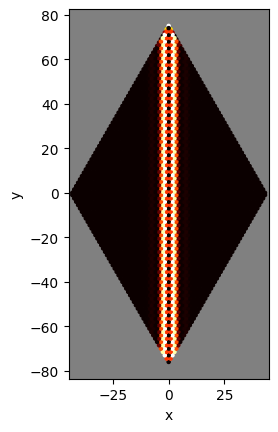

In [102]:
# psi_a, psi_b = psi_analytic(na[0], na[1], ky = 0, delta_0=0.5, lambda_0=2, tau=1)
psi_a, psi_b = full_psi(lattice, delta_0=0.5, lambda_0=2)
na, nb = lattice.n_real_pos
Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2


fig, ax = plt.subplots()

plot_graphene(na, nb, Cna, Cnb, ax)

ax.set_aspect("equal")
ax.set_xlim(-45, 45)

ax.set_facecolor("gray")

ax.set_ylabel("y")
ax.set_xlabel("x")

Text(0.5, 1.0, 'Parameters: $k_y = 0$, $\\Delta_0 = 0.5$, $\\lambda = 2$, $\\tau = 1$')

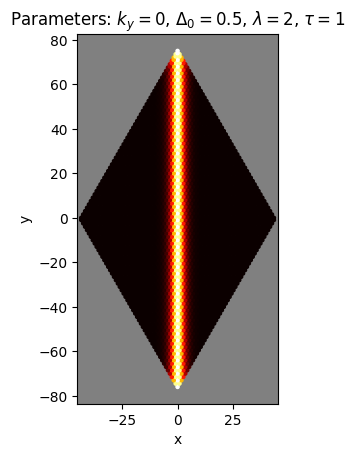

In [103]:
KY = 0
DELTA_0 = 0.5
LAMBDA_0= 2
TAU = 1

psi_a, psi_b = psi_analytic(na[0], na[1], ky = KY, delta_0=DELTA_0, lambda_0=LAMBDA_0, tau=TAU)
# psi_a, psi_b = full_psi(lattice, delta_0=0.5, lambda_0=2)
na, nb = lattice.n_real_pos
Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2


fig, ax = plt.subplots()

plot_graphene(na, nb, Cna, Cnb, ax)

ax.set_aspect("equal")
ax.set_xlim(-45, 45)

ax.set_facecolor("gray")

ax.set_ylabel("y")
ax.set_xlabel("x")

ax.set_title(f"Parameters: $k_y = {KY}$, $\\Delta_0 = {DELTA_0}$, $\\lambda = {LAMBDA_0}$, $\\tau = {TAU}$")

In [104]:
np.vdot(psi_a, psi_a)

np.complex128(34.3368995925613+0j)

In [105]:
psi_a, psi_b = psi_analytic(na[0], nb[0], ky = 0, delta_0=0.5, lambda_0=2, tau=1)
norm = np.sqrt(np.vdot(psi_a, psi_a))
norm

np.complex128(5.859769585279041+0j)

In [53]:
psi_a

array([0.37556277+0.j, 0.41132537+0.j, 0.52542409+0.j, ...,
       0.52542409+0.j, 0.41132537+0.j, 0.37556277+0.j])

In [52]:
norm

np.float64(1.3424892582731436e+18)

In [36]:
psi_a

array([0.37556277+0.j, 0.41132537+0.j, 0.52542409+0.j, ...,
       0.52542409+0.j, 0.41132537+0.j, 0.37556277+0.j])

In [20]:
np.vdot(psi_b, psi_b)

np.complex128(1.3424892582731436e+18+0j)

In [ ]:
np.vdot(psi_a, psi_b)

np.float64(0.0)